In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("mnist.csv")

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [5]:
df.shape

(42000, 785)

In [6]:
28*28

784

In [7]:
df.sample(2)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
30081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17290,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
import matplotlib.pyplot as plt 

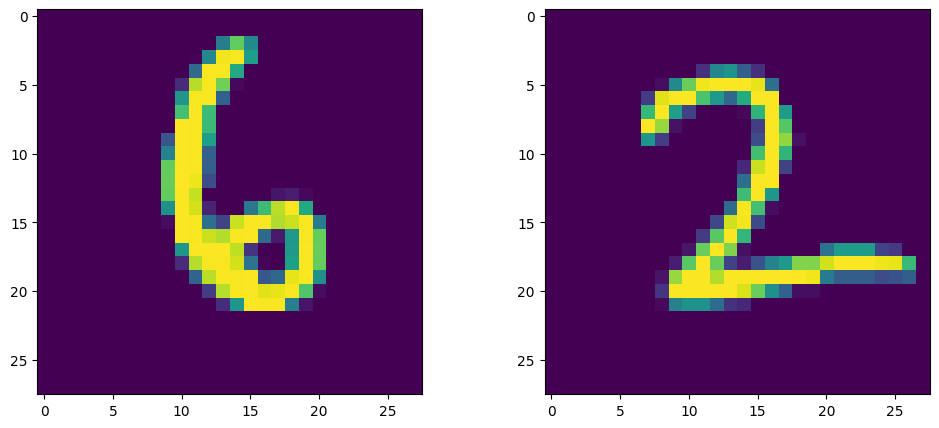

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(df.iloc[12457, 1:].values.reshape(28,28))

plt.subplot(122)
plt.imshow(df.iloc[12768, 1:].values.reshape(28,28))

plt.show()

In [10]:
df.sample(8)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
7489,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17148,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
808,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12404,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39227,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34109,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10023,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


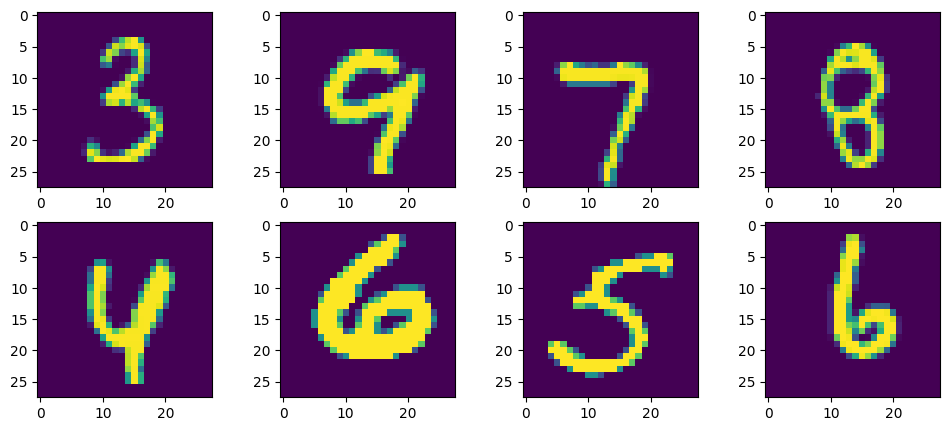

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(241)
plt.imshow(df.iloc[12320, 1:].values.reshape(28,28))

plt.subplot(242)
plt.imshow(df.iloc[27809, 1:].values.reshape(28,28))

plt.subplot(243)
plt.imshow(df.iloc[35446, 1:].values.reshape(28,28))

plt.subplot(244)
plt.imshow(df.iloc[12195, 1:].values.reshape(28,28))

plt.subplot(245)
plt.imshow(df.iloc[27808, 1:].values.reshape(28,28))

plt.subplot(246)
plt.imshow(df.iloc[18831, 1:].values.reshape(28,28))

plt.subplot(247)
plt.imshow(df.iloc[36539, 1:].values.reshape(28,28))

plt.subplot(248)
plt.imshow(df.iloc[34513, 1:].values.reshape(28,28))

plt.show()

In [12]:
X = df.iloc[:, 1:]
y = df.iloc[:,0]

In [13]:
X.head(2)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
y.head()

0    1
1    0
2    1
3    4
4    0
Name: label, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=43)

In [17]:
X_train.shape

(33600, 784)

In [18]:
X_test.shape

(8400, 784)

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
knn = KNeighborsClassifier()

In [21]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [22]:
y_pred = knn.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

In [24]:
accuracy_score(y_pred, y_test)

0.9685714285714285

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Now we will apply the PCA

In [29]:
from sklearn.decomposition import PCA

In [30]:
pca = PCA(n_components=200)

In [31]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [32]:
X_train_trf.shape

(33600, 200)

In [33]:
knn = KNeighborsClassifier()

In [34]:
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [35]:
y_pred = knn.predict(X_test_trf)

In [36]:
accuracy_score(y_pred, y_test)

0.9523809523809523

In [78]:
"""
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)

    print(accuracy_score(y_pred, y_test))
"""

0.25535714285714284
0.3277380952380952
0.5048809523809524
0.661547619047619
0.7335714285714285
0.8261904761904761
0.8453571428571428
0.8727380952380952
0.8878571428571429
0.9048809523809523
0.9130952380952381
0.9141666666666667
0.924404761904762
0.9332142857142857
0.9345238095238095
0.9360714285714286
0.9372619047619047
0.9376190476190476
0.9420238095238095
0.9444047619047619
0.9432142857142857
0.9446428571428571
0.9458333333333333
0.9477380952380953
0.9467857142857142
0.9473809523809524
0.9496428571428571
0.9489285714285715
0.9497619047619048
0.9508333333333333
0.9529761904761904
0.9534523809523809
0.9514285714285714
0.9532142857142857
0.9529761904761904
0.954047619047619
0.9535714285714286
0.9544047619047619
0.9541666666666667
0.9530952380952381
0.9542857142857143
0.9545238095238096
0.9536904761904762
0.9534523809523809
0.9546428571428571
0.9539285714285715
0.955952380952381
0.9546428571428571
0.9552380952380952
0.9561904761904761
0.955
0.9557142857142857
0.9553571428571429
0.9559523

KeyboardInterrupt: 

In [79]:
"""for i in range(1,785, 10):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)

    print(accuracy_score(y_pred, y_test))"""

0.25666666666666665
0.9122619047619047
0.9439285714285715
0.9528571428571428
0.9547619047619048
0.9552380952380952
0.955595238095238
0.9572619047619048
0.9567857142857142
0.9576190476190476
0.9564285714285714
0.9566666666666667
0.9558333333333333
0.9553571428571429
0.9542857142857143
0.9532142857142857
0.9523809523809523
0.9519047619047619
0.9525
0.9526190476190476
0.9528571428571428
0.9523809523809523
0.9511904761904761
0.950952380952381
0.9510714285714286
0.9498809523809524
0.9498809523809524
0.9488095238095238
0.9479761904761905
0.9477380952380953
0.9473809523809524
0.9467857142857142
0.9460714285714286
0.9454761904761905
0.9448809523809524
0.9451190476190476
0.9447619047619048
0.9442857142857143
0.9435714285714286
0.944047619047619
0.944047619047619
0.9433333333333334
0.9430952380952381
0.9421428571428572
0.9425
0.9416666666666667
0.9411904761904762
0.9414285714285714
0.9415476190476191
0.9408333333333333
0.9404761904761905
0.9408333333333333
0.940595238095238
0.9402380952380952
0.

In [80]:
# 94% is the accuracy at last

In [37]:
import plotly.express as px

In [38]:
y_train_trf = y_train.astype("str")

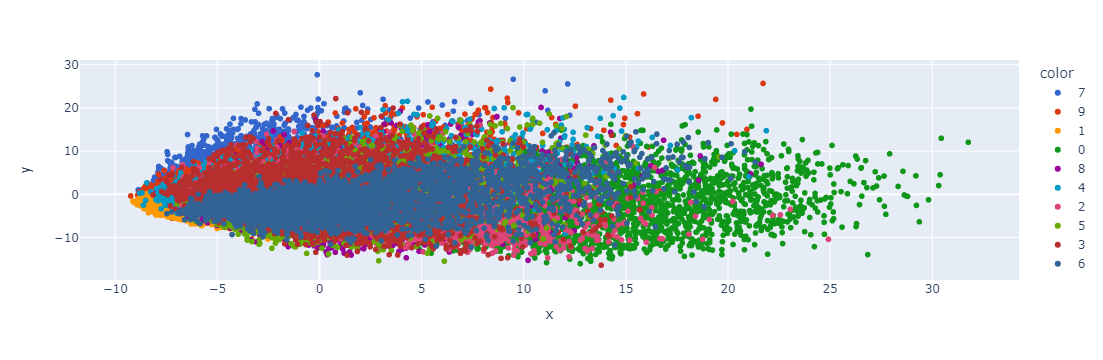

In [42]:
fig = px.scatter(x= X_train_trf[:,0], y = X_train_trf[:,1], color=y_train_trf, color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [43]:
# for 3D visualization
pca = PCA(n_components=3)
X_train_trf3d = pca.fit_transform(X_train)
X_test_trf3d = pca.transform(X_test)

In [44]:
X_train_trf3d

array([[-5.48598911, -2.4654187 , -0.02165665],
       [-2.32142683, -0.73132689, -7.90998025],
       [-5.4830858 , -5.34561855,  3.03331192],
       ...,
       [-3.73484814,  5.56170881, -3.54252223],
       [-6.2466968 , -0.87631537, -4.19233113],
       [-5.74676969, -3.72222005,  3.73390483]])

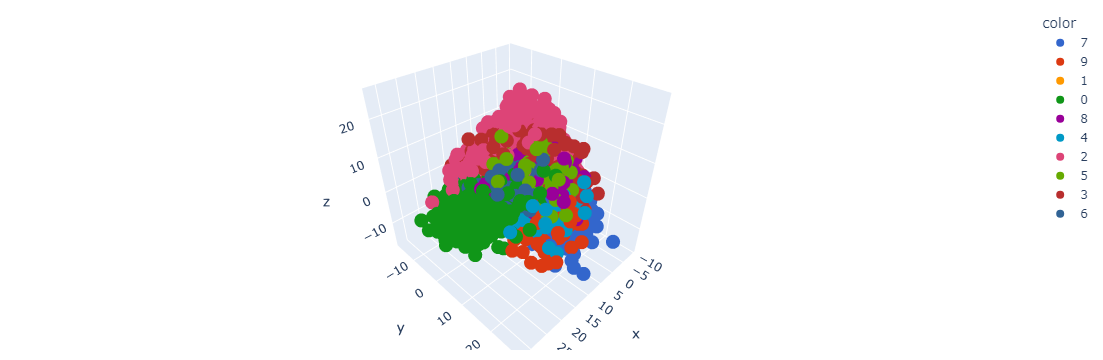

In [49]:
fig = px.scatter_3d(x= X_train_trf3d[:,0], y = X_train_trf3d[:,1], z = X_train_trf3d[:,2], color=y_train_trf, color_discrete_sequence=px.colors.qualitative.G10)
fig.update_layout(margin = dict(l=10, r=10, t=10, b=10))
fig.show()

In [51]:
pca.explained_variance_
# Eigen values

array([40.58305649, 29.18765684, 26.88929907])

In [53]:
pca.components_
# Eigen vectors

array([[ 1.33142434e-17,  8.63442518e-18,  2.74635359e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-3.65508375e-17, -2.32909990e-17, -4.24863308e-19, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-8.71619193e-17, -6.19384497e-17, -1.74437839e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [54]:
pca.components_.shape

(3, 784)

In [55]:
pca.explained_variance_ratio_

array([0.05772667, 0.04151748, 0.03824822])

In [57]:
pca = PCA(n_components=None)
X_train_trf_all = pca.fit_transform(X_train)
X_test_trf_all = pca.transform(X_test)

In [59]:
X_train_trf_all.shape

(33600, 784)

In [61]:
pca.explained_variance_.shape

(784,)

In [62]:
pca.components_.shape

(784, 784)

In [63]:
pca.explained_variance_ratio_

array([5.77266695e-02, 4.15174797e-02, 3.82482204e-02, 2.96553090e-02,
       2.57121506e-02, 2.25844181e-02, 1.96997383e-02, 1.78484920e-02,
       1.57560855e-02, 1.44114071e-02, 1.38142201e-02, 1.23024570e-02,
       1.14076273e-02, 1.12478915e-02, 1.05688711e-02, 1.01278458e-02,
       9.58347050e-03, 9.45686380e-03, 9.15366248e-03, 8.91462447e-03,
       8.45978634e-03, 8.16964134e-03, 7.80450220e-03, 7.55844453e-03,
       7.32988218e-03, 7.03993872e-03, 6.99468472e-03, 6.72420953e-03,
       6.37178998e-03, 6.26564033e-03, 6.15732591e-03, 6.03354910e-03,
       5.87885005e-03, 5.77687765e-03, 5.73363784e-03, 5.54627025e-03,
       5.43335255e-03, 5.33175304e-03, 5.15415149e-03, 4.92288004e-03,
       4.88512838e-03, 4.81855968e-03, 4.67610116e-03, 4.59482722e-03,
       4.57130950e-03, 4.49981596e-03, 4.45060793e-03, 4.43308454e-03,
       4.40180416e-03, 4.29254817e-03, 4.19699007e-03, 4.13931381e-03,
       4.07767573e-03, 4.01023021e-03, 3.97516912e-03, 3.91068904e-03,
      

In [64]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05772667, 0.09924415, 0.13749237, 0.16714768, 0.19285983,
       0.21544425, 0.23514399, 0.25299248, 0.26874856, 0.28315997,
       0.29697419, 0.30927665, 0.32068427, 0.33193217, 0.34250104,
       0.35262888, 0.36221235, 0.37166922, 0.38082288, 0.3897375 ,
       0.39819729, 0.40636693, 0.41417143, 0.42172988, 0.42905976,
       0.4360997 , 0.44309438, 0.44981859, 0.45619038, 0.46245602,
       0.46861335, 0.4746469 , 0.48052575, 0.48630263, 0.49203626,
       0.49758254, 0.50301589, 0.50834764, 0.51350179, 0.51842467,
       0.5233098 , 0.52812836, 0.53280446, 0.53739929, 0.5419706 ,
       0.54647041, 0.55092102, 0.55535411, 0.55975591, 0.56404846,
       0.56824545, 0.57238476, 0.57646244, 0.58047267, 0.58444784,
       0.58835853, 0.59214142, 0.59588856, 0.59957936, 0.60322789,
       0.60685048, 0.61038041, 0.61387668, 0.61729727, 0.62069552,
       0.62405788, 0.62738222, 0.63066909, 0.63393018, 0.63715418,
       0.64034577, 0.64345321, 0.64654037, 0.64961588, 0.65265

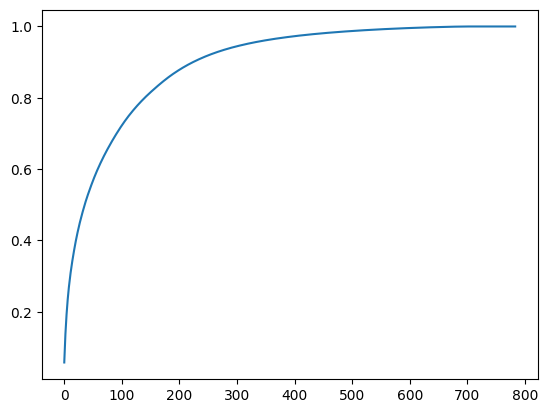

In [65]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))